In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda
import time
import math

# STEP 1: Generate Dataset
N = 10_000_000

np.random.seed(42)

# Highest CUDA-supported precision = float64
dataset = np.random.uniform(
    low=0.0,
    high=1e12,
    size=N
).astype(np.float64)

print("=" * 60)
print("DATASET GENERATED")
print("=" * 60)

print("Dataset Size :", len(dataset))
print("Datatype     :", dataset.dtype)

print("\nFirst 10 Values:")
for value in dataset[:10]:
    print(f"{value:.15f}")



DATASET GENERATED
Dataset Size : 10000000
Datatype     : float64

First 10 Values:
374540118847.362487792968750
950714306409.916137695312500
731993941811.405151367187500
598658484197.036621093750000
156018640442.436523437500000
155994520336.202636718750000
58083612168.199462890625000
866176145774.935180664062500
601115011743.208862304687500
708072577796.045532226562500


In [8]:

# STEP 2: CUDA Kernel
# Count values whose integer part is odd


@cuda.jit
def count_odd_integer_part_kernel(arr, odd_count):

    idx = cuda.grid(1)

    if idx < arr.size:

        integer_part = int(arr[idx])

        if integer_part % 2 == 1:
            cuda.atomic.add(odd_count, 0, 1)



In [9]:

# STEP 3: CUDA Execution Function


def count_odds_cuda(data):

    d_arr = cuda.to_device(data)

    odd_count = np.zeros(1, dtype=np.int64)

    d_odd_count = cuda.to_device(odd_count)

    threads_per_block = 256
    blocks_per_grid = math.ceil(
        len(data) / threads_per_block
    )

    start = time.time()

    count_odd_integer_part_kernel[
        blocks_per_grid,
        threads_per_block
    ](
        d_arr,
        d_odd_count
    )

    cuda.synchronize()

    gpu_time = time.time() - start

    result = d_odd_count.copy_to_host()[0]

    return result, gpu_time



In [10]:

# STEP 4: Execute On Small Sample


sample_data = dataset[:100]

sample_count, sample_time = count_odds_cuda(sample_data)

print("\n" + "=" * 60)
print("SAMPLE EXECUTION")
print("=" * 60)

print("Sample Size              :", len(sample_data))
print("Odd Integer Part Count   :", sample_count)
print("Execution Time (sec)     :", round(sample_time, 6))




SAMPLE EXECUTION
Sample Size              : 100
Odd Integer Part Count   : 54
Execution Time (sec)     : 0.063443


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [11]:

# STEP 5: Execute On Full Dataset

gpu_odd_count, gpu_time = count_odds_cuda(dataset)

gpu_even_count = len(dataset) - gpu_odd_count

print("\n" + "=" * 60)
print("CUDA RESULTS")
print("=" * 60)

print("Total Records            :", len(dataset))
print("Odd Integer Part Count   :", gpu_odd_count)
print("Even Integer Part Count  :", gpu_even_count)
print("CUDA Time (sec)          :", round(gpu_time, 4))




CUDA RESULTS
Total Records            : 10000000
Odd Integer Part Count   : 5001424
Even Integer Part Count  : 4998576
CUDA Time (sec)          : 0.0007



CPU VERIFICATION
CPU Odd Count            : 5001424
CPU Time (sec)           : 0.1672
Verification             : PASSED


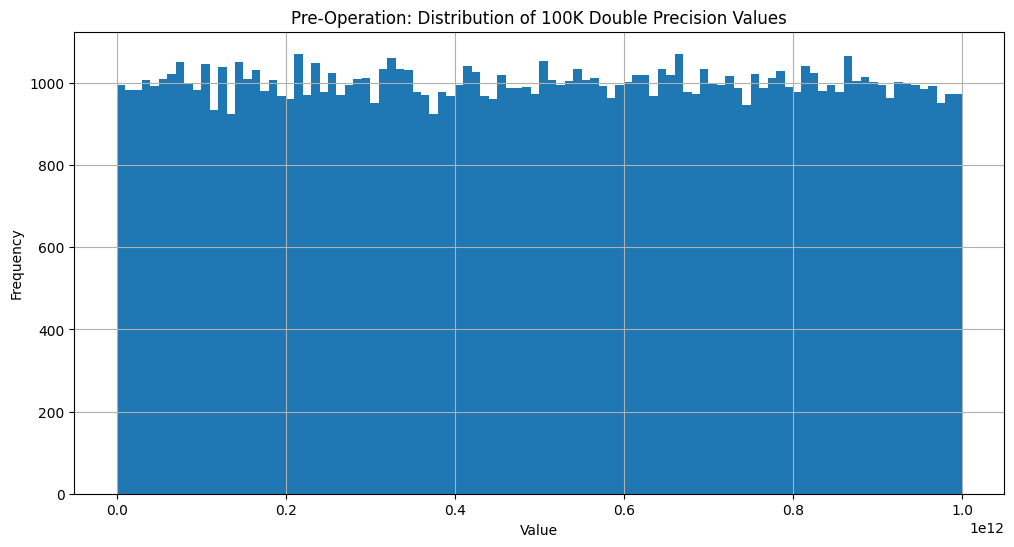

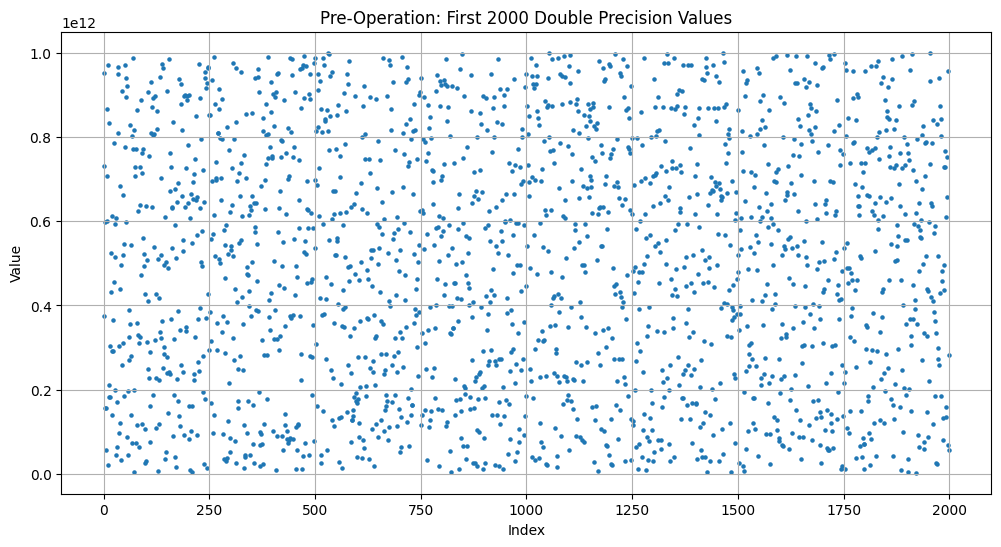

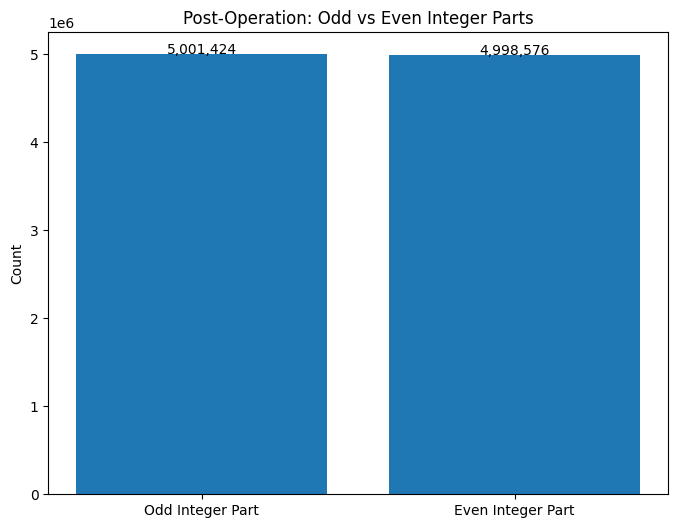

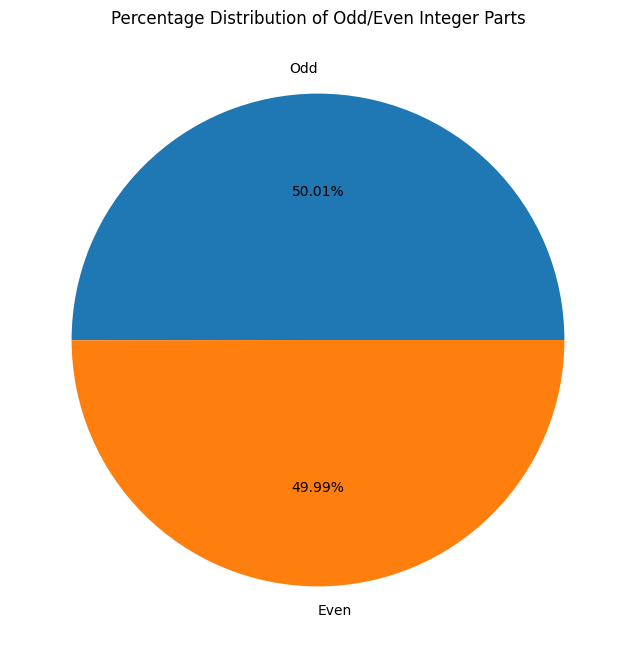


DOUBLE PRECISION CHECK
Value 1: 374540118847.362487792968750
Value 2: 950714306409.916137695312500
Value 3: 731993941811.405151367187500
Value 4: 598658484197.036621093750000
Value 5: 156018640442.436523437500000

DATASET STATISTICS
Dataset Size          : 10,000,000
Datatype              : float64
Minimum Value         : 337120.857119010936003
Maximum Value         : 999999916511.420410156250000
Mean Value            : 499992480383.626342773437500
Median Value          : 500021628595.377807617187500
Standard Deviation    : 288674870636.644287109375000

Odd/Even Statistics
Odd Integer Parts     : 5,001,424
Even Integer Parts    : 4,998,576
Odd Percentage        : 50.0142%
Even Percentage       : 49.9858%

Performance
CUDA Execution Time   : 0.0007 sec
CPU Execution Time    : 0.1672 sec
GPU Speedup           : 255.34x


In [12]:

# STEP 6: CPU Verification


cpu_start = time.time()

cpu_odd_count = np.sum(
    dataset.astype(np.int64) % 2 == 1
)

cpu_time = time.time() - cpu_start

print("\n" + "=" * 60)
print("CPU VERIFICATION")
print("=" * 60)

print("CPU Odd Count            :", cpu_odd_count)
print("CPU Time (sec)           :", round(cpu_time, 4))

if cpu_odd_count == gpu_odd_count:
    print("Verification             : PASSED")
else:
    print("Verification             : FAILED")


# STEP 7: PRE-OPERATION VISUALIZATION
# Distribution of Floating Point Values


plt.figure(figsize=(12, 6))

plt.hist(
    dataset[:100000],
    bins=100
)

plt.title(
    "Pre-Operation: Distribution of 100K Double Precision Values"
)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()


# STEP 8: PRE-OPERATION SCATTER PLOT


plt.figure(figsize=(12, 6))

plt.scatter(
    np.arange(2000),
    dataset[:2000],
    s=5
)

plt.title(
    "Pre-Operation: First 2000 Double Precision Values"
)

plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True)

plt.show()


# STEP 9: POST-OPERATION VISUALIZATION
# Odd vs Even Integer Parts


labels = [
    "Odd Integer Part",
    "Even Integer Part"
]

counts = [
    gpu_odd_count,
    gpu_even_count
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    labels,
    counts
)

plt.title(
    "Post-Operation: Odd vs Even Integer Parts"
)

plt.ylabel("Count")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha='center'
    )

plt.show()


# STEP 10: PIE CHART


odd_percentage = (
    gpu_odd_count / len(dataset)
) * 100

even_percentage = (
    gpu_even_count / len(dataset)
) * 100

plt.figure(figsize=(8, 8))

plt.pie(
    [odd_percentage, even_percentage],
    labels=["Odd", "Even"],
    autopct="%1.2f%%"
)

plt.title(
    "Percentage Distribution of Odd/Even Integer Parts"
)

plt.show()

# STEP 11: PRECISION CHECK

print("\n" + "=" * 60)
print("DOUBLE PRECISION CHECK")
print("=" * 60)

for i in range(5):
    print(
        f"Value {i+1}: "
        f"{dataset[i]:.15f}"
    )

# STEP 12: STATISTICS REPORT

print("\n" + "=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print(f"Dataset Size          : {len(dataset):,}")
print(f"Datatype              : {dataset.dtype}")

print(f"Minimum Value         : {dataset.min():.15f}")
print(f"Maximum Value         : {dataset.max():.15f}")

print(f"Mean Value            : {dataset.mean():.15f}")
print(f"Median Value          : {np.median(dataset):.15f}")

print(f"Standard Deviation    : {dataset.std():.15f}")

print("\nOdd/Even Statistics")

print(f"Odd Integer Parts     : {gpu_odd_count:,}")
print(f"Even Integer Parts    : {gpu_even_count:,}")

print(f"Odd Percentage        : {odd_percentage:.4f}%")
print(f"Even Percentage       : {even_percentage:.4f}%")

print("\nPerformance")

print(f"CUDA Execution Time   : {gpu_time:.4f} sec")
print(f"CPU Execution Time    : {cpu_time:.4f} sec")

if gpu_time > 0:
    print(
        f"GPU Speedup           : "
        f"{cpu_time / gpu_time:.2f}x"
    )